<a href="https://colab.research.google.com/github/AyanBekbossyn/Data-Driven-Strategic-Decision-Making/blob/main/B107.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:

G = nx.read_edgelist("facebook_combined.txt", nodetype=int)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 4039
Number of edges: 88234


In [3]:

n = G.number_of_nodes()
m = G.number_of_edges()

print("Nodes:", n)
print("Edges:", m)


Nodes: 4039
Edges: 88234


In [4]:
density = nx.density(G)
avg_clustering = nx.average_clustering(G)
degrees = [d for _, d in G.degree()]
avg_degree = sum(degrees) / len(degrees)
min_degree = min(degrees)
max_degree = max(degrees)

print("Density:", density)
print("Average clustering coefficient:", avg_clustering)
print("Average degree:", avg_degree)
print("Minimum degree:", min_degree)
print("Maximum degree:", max_degree)

Density: 0.010819963503439287
Average clustering coefficient: 0.6055467186200862
Average degree: 43.69101262688784
Minimum degree: 1
Maximum degree: 1045


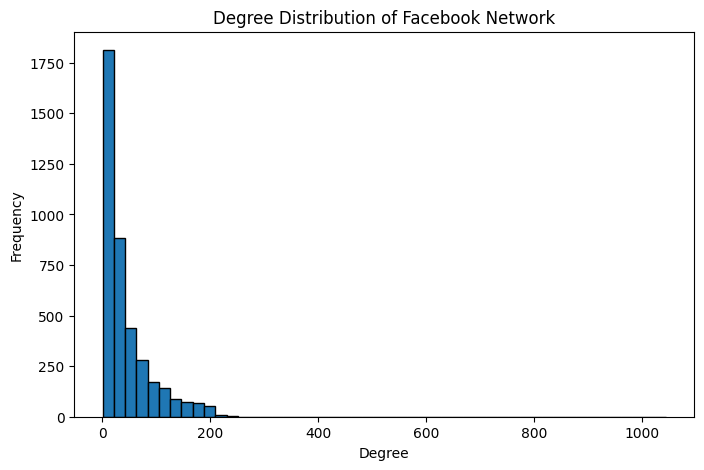

In [5]:
plt.figure(figsize=(8,5))
plt.hist(degrees, bins=50, edgecolor='black')
plt.title("Degree Distribution of Facebook Network")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

In [6]:
components = list(nx.connected_components(G))
largest_cc = max(components, key=len)
G_lcc = G.subgraph(largest_cc).copy()

print("Number of connected components:", len(components))
print("Size of largest connected component:", len(largest_cc))

Number of connected components: 1
Size of largest connected component: 4039


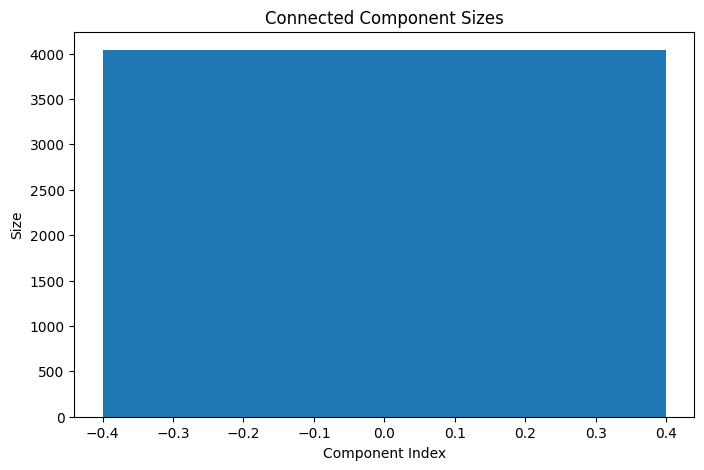

In [7]:
component_sizes = sorted([len(c) for c in components], reverse=True)

plt.figure(figsize=(8,5))
plt.bar(range(len(component_sizes)), component_sizes)
plt.title("Connected Component Sizes")
plt.xlabel("Component Index")
plt.ylabel("Size")
plt.show()

In [8]:
avg_path_length = nx.average_shortest_path_length(G_lcc)
diameter = nx.diameter(G_lcc)

print("Average shortest path length (largest CC):", avg_path_length)
print("Diameter (largest CC):", diameter)

Average shortest path length (largest CC): 3.6925068496963913
Diameter (largest CC): 8


In [9]:
degree_centrality = nx.degree_centrality(G)
top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 nodes by degree centrality:")
for node, value in top_degree:
    print(node, value)

Top 10 nodes by degree centrality:
107 0.258791480931154
1684 0.1961367013372957
1912 0.18697374938088163
3437 0.13546310054482416
0 0.08593363051015354
2543 0.07280832095096582
2347 0.07206537890044576
1888 0.0629024269440317
1800 0.06067360079247152
1663 0.058197127290737984


In [10]:
closeness_centrality = nx.closeness_centrality(G_lcc)
top_closeness = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 nodes by closeness centrality:")
for node, value in top_closeness:
    print(node, value)

Top 10 nodes by closeness centrality:
107 0.45969945355191255
58 0.3974018305284913
428 0.3948371956585509
563 0.3939127889961955
1684 0.39360561458231796
171 0.37049270575282134
348 0.36991572004397216
483 0.3698479575013739
414 0.3695433330282786
376 0.36655773420479304


In [11]:
betweenness_centrality = nx.betweenness_centrality(G_lcc, k=100, seed=42)
top_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 nodes by betweenness centrality:")
for node, value in top_betweenness:
    print(node, value)

Top 10 nodes by betweenness centrality:
107 0.49713415325127436
1684 0.3458416454521182
1912 0.23592994003213882
3437 0.18749318958009067
0 0.15731261380098313
1085 0.1311418130718408
698 0.09261188521856868
58 0.09186542072879204
567 0.07588391490039662
428 0.06158933149273648


In [12]:
top_degree_df = pd.DataFrame(top_degree, columns=["Node", "Degree Centrality"])
top_closeness_df = pd.DataFrame(top_closeness, columns=["Node", "Closeness Centrality"])
top_betweenness_df = pd.DataFrame(top_betweenness, columns=["Node", "Betweenness Centrality"])

print(top_degree_df)
print(top_closeness_df)
print(top_betweenness_df)

   Node  Degree Centrality
0   107           0.258791
1  1684           0.196137
2  1912           0.186974
3  3437           0.135463
4     0           0.085934
5  2543           0.072808
6  2347           0.072065
7  1888           0.062902
8  1800           0.060674
9  1663           0.058197
   Node  Closeness Centrality
0   107              0.459699
1    58              0.397402
2   428              0.394837
3   563              0.393913
4  1684              0.393606
5   171              0.370493
6   348              0.369916
7   483              0.369848
8   414              0.369543
9   376              0.366558
   Node  Betweenness Centrality
0   107                0.497134
1  1684                0.345842
2  1912                0.235930
3  3437                0.187493
4     0                0.157313
5  1085                0.131142
6   698                0.092612
7    58                0.091865
8   567                0.075884
9   428                0.061589


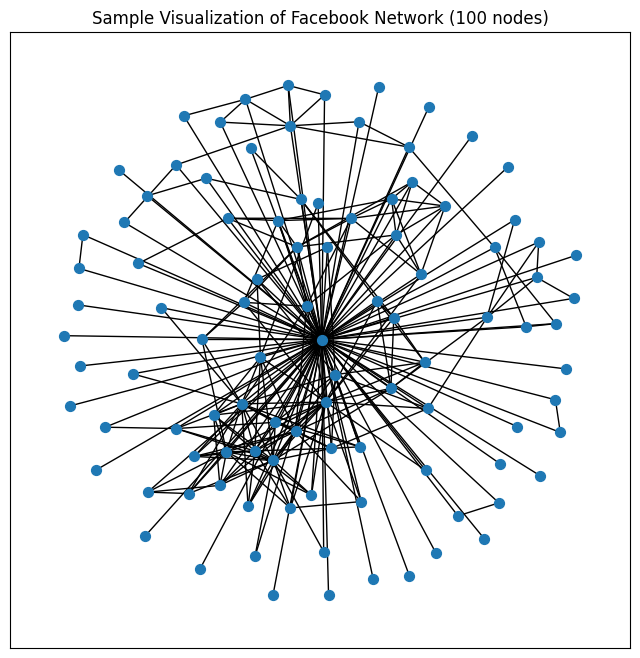

In [13]:
sample_nodes = list(G.nodes())[:100]
G_sample = G.subgraph(sample_nodes)

plt.figure(figsize=(8,8))
nx.draw_networkx(G_sample, node_size=50, with_labels=False)
plt.title("Sample Visualization of Facebook Network (100 nodes)")
plt.show()

In [14]:
n = G.number_of_nodes()
m = G.number_of_edges()

# ER graph
p = (2 * m) / (n * (n - 1))
ER = nx.erdos_renyi_graph(n, p, seed=42)

# BA graph
m_ba = max(1, round(m / n))
BA = nx.barabasi_albert_graph(n, m_ba, seed=42)

# WS graph
k_ws = max(2, round((2 * m) / n))
if k_ws % 2 != 0:
    k_ws += 1
WS = nx.watts_strogatz_graph(n, k_ws, 0.1, seed=42)

print("ER:", ER.number_of_nodes(), ER.number_of_edges())
print("BA:", BA.number_of_nodes(), BA.number_of_edges())
print("WS:", WS.number_of_nodes(), WS.number_of_edges())

ER: 4039 87553
BA: 4039 88374
WS: 4039 88858


In [15]:
def graph_metrics(graph, name):
    largest_cc = max(nx.connected_components(graph), key=len)
    g_sub = graph.subgraph(largest_cc).copy()

    return {
        "Graph": name,
        "Nodes": graph.number_of_nodes(),
        "Edges": graph.number_of_edges(),
        "Density": nx.density(graph),
        "Avg Clustering": nx.average_clustering(graph),
        "Avg Degree": sum(dict(graph.degree()).values()) / graph.number_of_nodes(),
        "Largest CC Size": len(largest_cc),
        "Avg Path Length": nx.average_shortest_path_length(g_sub)
    }

comparison_df = pd.DataFrame([
    graph_metrics(G, "Facebook"),
    graph_metrics(ER, "ER"),
    graph_metrics(BA, "BA"),
    graph_metrics(WS, "WS")
])

comparison_df

,Graph,Nodes,Edges,Density,Avg Clustering,Avg Degree,Largest CC Size,Avg Path Length
0,Facebook,4039,88234,0.010820,0.605547,43.691013,4039,3.692507
1,ER,4039,87553,0.010736,0.010766,43.353800,4039,2.610505
2,BA,4039,88374,0.010837,0.038214,43.760337,4039,2.507594
3,WS,4039,88858,0.010896,0.534717,44.000000,4039,2.964702


In [18]:
facebook_degrees = [d for _, d in G.degree()]
er_degrees = [d for _, d in ER.degree()]
ba_degrees = [d for _, d in BA.degree()]
ws_degrees = [d for _, d in WS.degree()]

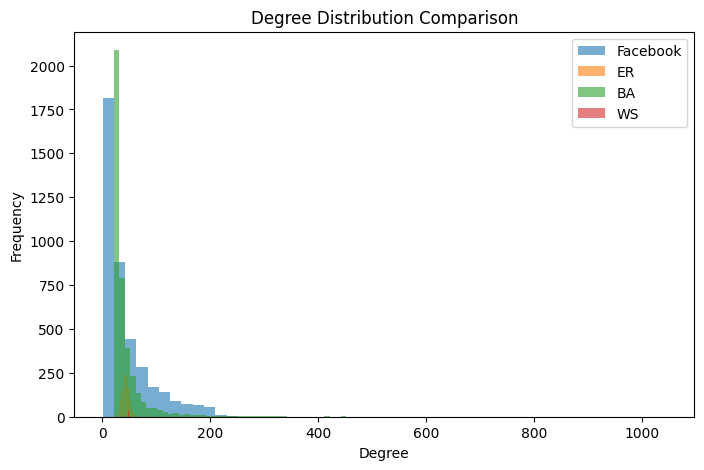

In [19]:
plt.figure(figsize=(8,5))
plt.hist(facebook_degrees, bins=50, alpha=0.6, label="Facebook")
plt.hist(er_degrees, bins=50, alpha=0.6, label="ER")
plt.hist(ba_degrees, bins=50, alpha=0.6, label="BA")
plt.hist(ws_degrees, bins=50, alpha=0.6, label="WS")
plt.title("Degree Distribution Comparison")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.legend()
plt.show()